# Curve Fitting & Regression
Fit linear, polynomial and exponential models to understand how each process parameter relates to Q-factor.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
CSV_PATH = 'qfactors_1.0um.csv'

## 1. Load & Aggregate

In [2]:
df = pd.read_csv(CSV_PATH)
df = df[df['q_factor'].notna() & df['q_factor'].between(0, 1)]

# Per-image aggregation
meta_cols = ['filename', 'Power(W)', 'Scanning speed(mm/s)', 'Pass', 'Range(micron)']
img = df.drop_duplicates('filename')[meta_cols].copy()
img = img.rename(columns={
    'Power(W)': 'power',
    'Scanning speed(mm/s)': 'scan_speed',
    'Pass': 'n_pass',
    'Range(micron)': 'range_um',
})

q_img = df.groupby('filename')['q_factor'].median().reset_index()
q_img.columns = ['filename', 'q_median']
img = img.merge(q_img, on='filename')

print(f'Images: {len(img)}')
print(img[['power', 'scan_speed', 'n_pass', 'range_um', 'q_median']].describe().round(3))

Images: 423
         power  scan_speed   n_pass  range_um  q_median
count  423.000     423.000  423.000   423.000   423.000
mean     1.771    1365.437    9.364    13.241     0.859
std      0.098     880.141    7.747     6.171     0.163
min      1.650      10.000    1.000     3.200     0.099
25%      1.650     600.000    5.000     8.000     0.802
50%      1.850    1250.000   10.000    13.600     0.920
75%      1.850    2050.000   15.000    16.800     0.970
max      1.850    3000.000   50.000    37.600     1.000


## 2. Model Definitions

In [3]:
def linear(x, a, b):
    return a * x + b

def poly2(x, a, b, c):
    return a * x**2 + b * x + c

def poly3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

MODELS = {
    'Linear':      linear,
    'Poly deg-2':  poly2,
    'Poly deg-3':  poly3,
    'Exponential': exponential,
}

## 3. Fitting Utility

In [4]:
def fit_models(x, y, models=MODELS):
    """
    Fit all models to (x, y) data.
    Returns a dict with fit results sorted by R².
    """
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)

    # Smart initial guesses based on data statistics
    p0_map = {
        'Linear':      [0, y.mean()],
        'Poly deg-2':  [0, 0, y.mean()],
        'Poly deg-3':  [0, 0, 0, y.mean()],
        # a * exp(b * x) + c: start with tiny b to avoid overflow
        'Exponential': [y.std(), 1e-4 * np.sign(np.corrcoef(x, y)[0, 1]), y.mean()],
    }

    results = {}
    for name, fn in models.items():
        try:
            popt, _ = curve_fit(fn, x, y, p0=p0_map[name], maxfev=10000)
            y_pred = fn(x, *popt)
            r2   = r2_score(y, y_pred)
            rmse = np.sqrt(mean_squared_error(y, y_pred))
            results[name] = {'params': popt, 'r2': r2, 'rmse': rmse, 'fn': fn}
        except Exception:
            results[name] = {'params': None, 'r2': np.nan, 'rmse': np.nan, 'fn': fn}

    return dict(sorted(results.items(), key=lambda x: x[1]['r2'], reverse=True))


def plot_fits(x, y, results, xlabel, title, top_n=3):
    """Scatter plot with top_n best fits overlaid."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(x, y, alpha=0.5, s=25, color='steelblue', label='Data', zorder=3)

    x_line = np.linspace(x.min(), x.max(), 300)
    colors = ['red', 'orange', 'green', 'purple']

    for i, (name, res) in enumerate(list(results.items())[:top_n]):
        if res['params'] is not None:
            y_line = res['fn'](x_line, *res['params'])
            ax.plot(x_line, y_line, color=colors[i], linewidth=2,
                    label=f"{name}  R²={res['r2']:.3f}  RMSE={res['rmse']:.3f}")

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Median Q-Factor')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def print_summary(results):
    print(f"{'Model':<15} {'R²':>8} {'RMSE':>8}")
    print('-' * 33)
    for name, res in results.items():
        r2   = f"{res['r2']:.4f}"   if not np.isnan(res['r2'])   else '  failed'
        rmse = f"{res['rmse']:.4f}" if not np.isnan(res['rmse']) else '  failed'
        print(f"{name:<15} {r2:>8} {rmse:>8}")

## 4. Q vs Scan Speed

Model                 R²     RMSE
---------------------------------
Poly deg-3        0.1626   0.1487
Poly deg-2        0.1338   0.1513
Linear            0.1016   0.1540
Exponential       0.1016   0.1540


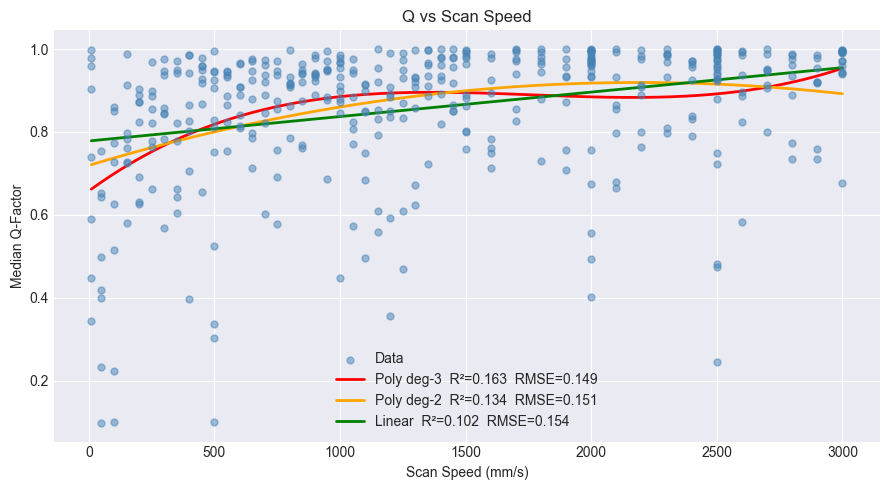

In [5]:
x, y = img['scan_speed'], img['q_median']
results_speed = fit_models(x, y)
print_summary(results_speed)
plot_fits(x, y, results_speed, xlabel='Scan Speed (mm/s)', title='Q vs Scan Speed')

## 5. Q vs Number of Passes

Model                 R²     RMSE
---------------------------------
Poly deg-3        0.0832   0.1556
Poly deg-2        0.0824   0.1557
Linear            0.0773   0.1561
Exponential       0.0773   0.1561


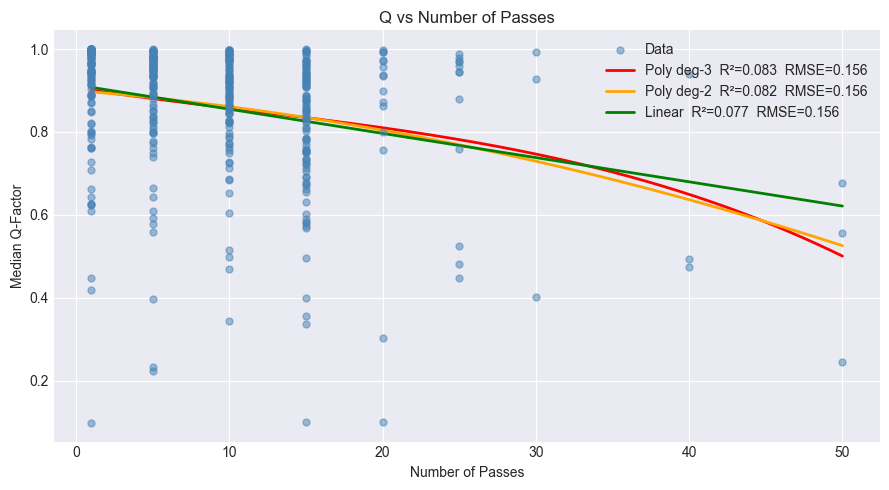

In [6]:
x, y = img['n_pass'], img['q_median']
results_pass = fit_models(x, y)
print_summary(results_pass)
plot_fits(x, y, results_pass, xlabel='Number of Passes', title='Q vs Number of Passes')

## 6. Q vs Range

Model                 R²     RMSE
---------------------------------
Poly deg-3        0.0664   0.1570
Poly deg-2        0.0664   0.1570
Exponential       0.0622   0.1574
Linear            0.0448   0.1588


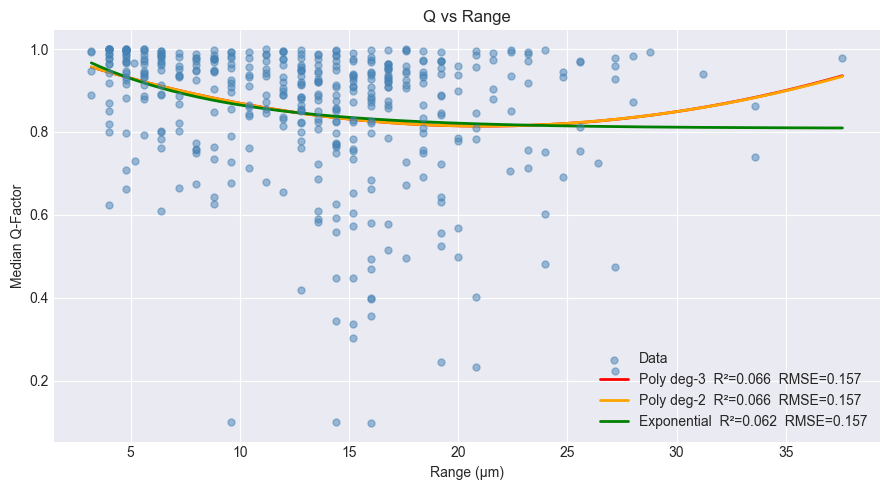

In [7]:
x, y = img['range_um'], img['q_median']
results_range = fit_models(x, y)
print_summary(results_range)
plot_fits(x, y, results_range, xlabel='Range (µm)', title='Q vs Range')

## 7. Q vs Power

Model                 R²     RMSE
---------------------------------
Linear            0.0118   0.1616
Poly deg-2        0.0118   0.1616
Poly deg-3        0.0118   0.1616
Exponential       0.0118   0.1616


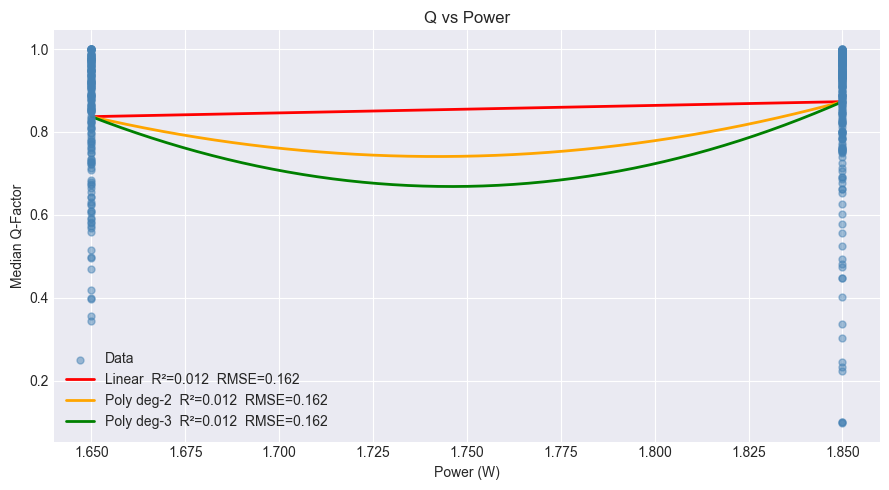

In [8]:
x, y = img['power'], img['q_median']
results_power = fit_models(x, y)
print_summary(results_power)
plot_fits(x, y, results_power, xlabel='Power (W)', title='Q vs Power')

## 8. Summary

In [9]:
all_results = {
    'scan_speed': results_speed,
    'n_pass':     results_pass,
    'range_um':   results_range,
    'power':      results_power,
}

rows = []
for param, res in all_results.items():
    best_name = list(res.keys())[0]
    best = res[best_name]
    rows.append({
        'parameter':  param,
        'best_model': best_name,
        'R²':         round(best['r2'], 4),
        'RMSE':       round(best['rmse'], 4),
    })

summary = pd.DataFrame(rows).sort_values('R²', ascending=False)
print('Best model per parameter (ranked by R²):')
print(summary.to_string(index=False))

Best model per parameter (ranked by R²):
 parameter best_model     R²   RMSE
scan_speed Poly deg-3 0.1626 0.1487
    n_pass Poly deg-3 0.0832 0.1556
  range_um Poly deg-3 0.0664 0.1570
     power     Linear 0.0118 0.1616


## 9. Multi-Parameter Regression
Combine all process parameters into a single model to capture combined and interaction effects.

In [10]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

FEATURES = ['scan_speed', 'n_pass', 'range_um', 'power']
X = img[FEATURES].values
y = img['q_median'].values

# --- Multi-linear (all 4 features, no interactions) ---
lr = LinearRegression()
cv_r2_lr = cross_val_score(lr, X, y, cv=5, scoring='r2').mean()
lr.fit(X, y)
y_pred_lr = lr.predict(X)
r2_lr   = r2_score(y, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y, y_pred_lr))

# Standardized coefficients for interpretability
x_std    = (X - X.mean(0)) / X.std(0)
lr_std   = LinearRegression().fit(x_std, y)

print('Multi-linear (all 4 features)')
print(f'  Train R²: {r2_lr:.4f}   RMSE: {rmse_lr:.4f}')
print(f'  CV R²:    {cv_r2_lr:.4f}')
print()
print('  Standardized coefficients (larger |value| = stronger effect):')
for feat, coef in zip(FEATURES, lr_std.coef_):
    print(f'    {feat:<12}: {coef:+.4f}')


Multi-linear (all 4 features)
  Train R²: 0.2364   RMSE: 0.1420
  CV R²:    0.0407

  Standardized coefficients (larger |value| = stronger effect):
    scan_speed  : +0.0630
    n_pass      : -0.0690
    range_um    : +0.0140
    power       : +0.0195


In [11]:
# --- Poly deg-2 with all pairwise interactions + Ridge ---
# Ridge regularisation handles n_pass <-> range_um collinearity (r=0.66)
model_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    Ridge(alpha=1.0),
)
cv_r2_poly = cross_val_score(model_poly, X, y, cv=5, scoring='r2').mean()
model_poly.fit(X, y)
y_pred_poly = model_poly.predict(X)
r2_poly   = r2_score(y, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))

print('Poly deg-2 + Ridge (all interactions)')
print(f'  Train R²: {r2_poly:.4f}   RMSE: {rmse_poly:.4f}')
print(f'  CV R²:    {cv_r2_poly:.4f}')

poly_step  = model_poly.named_steps['polynomialfeatures']
ridge_step = model_poly.named_steps['ridge']
feat_names = poly_step.get_feature_names_out(FEATURES)
top_idx    = np.argsort(np.abs(ridge_step.coef_))[::-1][:8]
print()
print('  Top 8 terms by |coefficient|:')
for i in top_idx:
    print(f'    {feat_names[i]:<25}: {ridge_step.coef_[i]:+.4f}')


Poly deg-2 + Ridge (all interactions)
  Train R²: 0.3189   RMSE: 0.1341
  CV R²:    0.1280

  Top 8 terms by |coefficient|:
    scan_speed power         : +0.1808
    scan_speed^2             : -0.0968
    n_pass                   : -0.0733
    scan_speed               : -0.0682
    n_pass^2                 : -0.0624
    scan_speed range_um      : +0.0510
    range_um                 : -0.0443
    range_um^2               : +0.0413


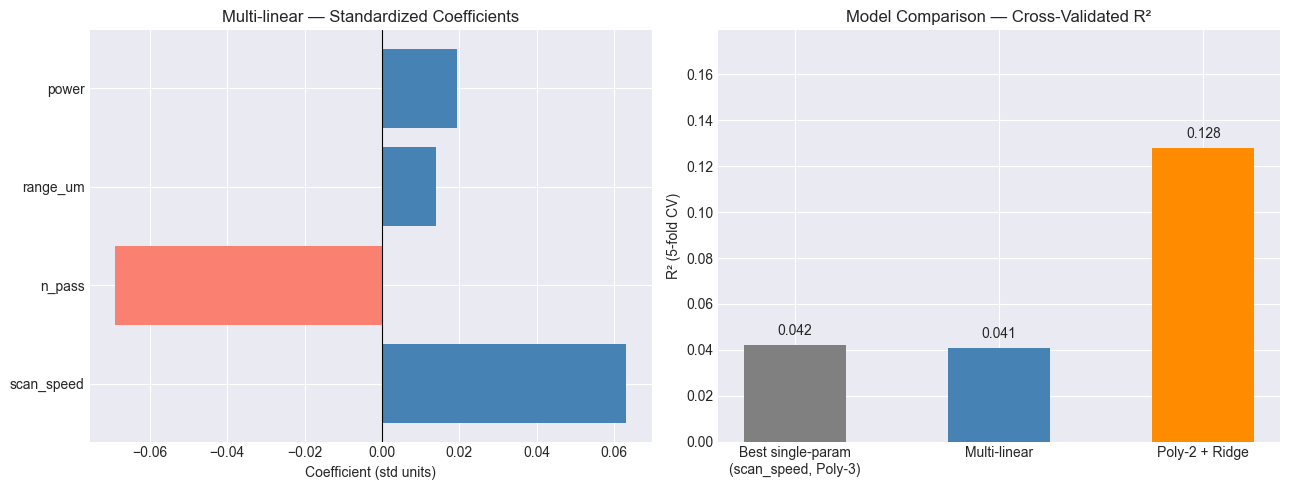

In [12]:
# CV reference: best single-param model (scan_speed, Poly deg-3)
pipe_speed   = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
cv_r2_speed  = cross_val_score(pipe_speed, img[['scan_speed']].values, y, cv=5, scoring='r2').mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: standardized coefficients
bar_colors = ['steelblue' if c > 0 else 'salmon' for c in lr_std.coef_]
axes[0].barh(FEATURES, lr_std.coef_, color=bar_colors)
axes[0].axvline(0, color='k', linewidth=0.8)
axes[0].set_title('Multi-linear — Standardized Coefficients')
axes[0].set_xlabel('Coefficient (std units)')

# Right: CV R² comparison
labels   = ['Best single-param\n(scan_speed, Poly-3)', 'Multi-linear', 'Poly-2 + Ridge']
cv_r2s   = [cv_r2_speed, cv_r2_lr, cv_r2_poly]
clrs     = ['gray', 'steelblue', 'darkorange']
bars     = axes[1].bar(labels, cv_r2s, color=clrs, width=0.5)
axes[1].set_ylabel('R² (5-fold CV)')
axes[1].set_title('Model Comparison — Cross-Validated R²')
axes[1].set_ylim(0, max(max(cv_r2s) * 1.4, 0.1))
for bar, val in zip(bars, cv_r2s):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 10. A and R Component Analysis
Q = 1 − R/A. Instead of fitting Q directly, model the two components separately.
If one of them has a stronger relationship with process parameters, that tells us
where the predictability actually lies — and why Q is hard to model.

In [13]:
# ── Aggregate A and R per image (same filter as q_factor) ────────────────────
ar = df.groupby('filename')[['A', 'R']].median().reset_index()
ar.columns = ['filename', 'A_median', 'R_median']
img2 = img.merge(ar, on='filename')

print(f"A: mean={img2['A_median'].mean():.1f}  std={img2['A_median'].std():.1f}  nm\u00b7\u00b5m")
print(f"R: mean={img2['R_median'].mean():.1f}  std={img2['R_median'].std():.1f}  nm\u00b7\u00b5m")

# ── Fit all params for A and R (reuse fit_models) ────────────────────────────
results_A, results_R = {}, {}
for feat in FEATURES:
    results_A[feat] = fit_models(img2[feat], img2['A_median'])
    results_R[feat] = fit_models(img2[feat], img2['R_median'])

# ── Comparison table: Q vs A vs R ────────────────────────────────────────────
print(f"\n{'Parameter':<12} {'Q R\u00b2':>8} {'A R\u00b2':>8} {'R R\u00b2':>8}  Best target")
print('-' * 54)
for feat in FEATURES:
    q_r2 = list(all_results[feat].values())[0]['r2']
    a_r2 = list(results_A[feat].values())[0]['r2']
    r_r2 = list(results_R[feat].values())[0]['r2']
    best = max(zip([q_r2, a_r2, r_r2], ['Q', 'A', 'R']), key=lambda x: x[0])
    print(f"{feat:<12} {q_r2:>8.4f} {a_r2:>8.4f} {r_r2:>8.4f}  ← {best[1]}")


A: mean=56.5  std=45.7  nm·µm
R: mean=6.7  std=7.6  nm·µm

Parameter        Q R²     A R²     R R²  Best target
------------------------------------------------------
scan_speed     0.1626   0.0355   0.1699  ← R
n_pass         0.0832   0.4329   0.2445  ← A
range_um       0.0664   0.5066   0.2745  ← A
power          0.0118   0.0860   0.0020  ← A


Multi-param Poly-2+Ridge  CV R²:
  Q : 0.128
  A : 0.491
  R : 0.431


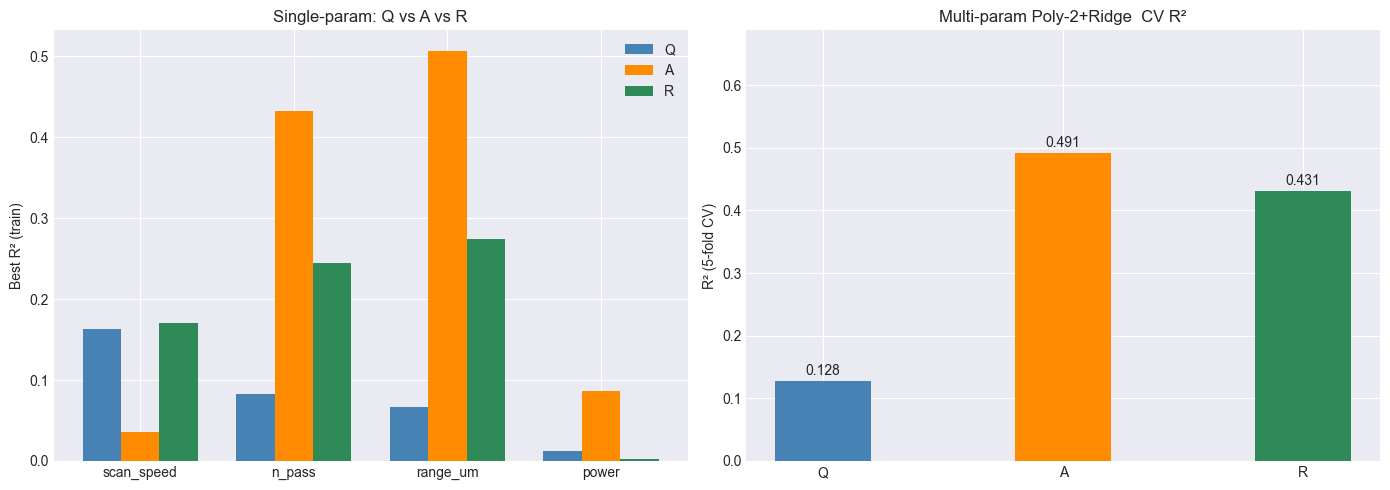

In [14]:
# ── Multi-param (Poly-2 + Ridge) for A and R ─────────────────────────────────
X2   = img2[FEATURES].values
y_A  = img2['A_median'].values
y_R  = img2['R_median'].values

pipe_A = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), StandardScaler(), Ridge(alpha=1.0))
pipe_R = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), StandardScaler(), Ridge(alpha=1.0))

cv_A = cross_val_score(pipe_A, X2, y_A, cv=5, scoring='r2').mean()
cv_R = cross_val_score(pipe_R, X2, y_R, cv=5, scoring='r2').mean()

print('Multi-param Poly-2+Ridge  CV R\u00b2:')
print(f'  Q : {cv_r2_poly:.3f}')
print(f'  A : {cv_A:.3f}')
print(f'  R : {cv_R:.3f}')

# ── Plot 1: grouped bar — single-param best R\u00b2 per feature ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos   = np.arange(len(FEATURES))
width   = 0.25
q_r2s   = [list(all_results[f].values())[0]['r2'] for f in FEATURES]
a_r2s   = [list(results_A[f].values())[0]['r2']   for f in FEATURES]
r_r2s   = [list(results_R[f].values())[0]['r2']   for f in FEATURES]

axes[0].bar(x_pos - width, q_r2s, width, label='Q', color='steelblue')
axes[0].bar(x_pos,         a_r2s, width, label='A', color='darkorange')
axes[0].bar(x_pos + width, r_r2s, width, label='R', color='seagreen')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(FEATURES)
axes[0].set_ylabel('Best R\u00b2 (train)')
axes[0].set_title('Single-param: Q vs A vs R')
axes[0].legend()

# ── Plot 2: multi-param CV R\u00b2 comparison ───────────────────────────────────
labels2  = ['Q', 'A', 'R']
cv_vals  = [cv_r2_poly, cv_A, cv_R]
clrs2    = ['steelblue', 'darkorange', 'seagreen']
bars2    = axes[1].bar(labels2, cv_vals, color=clrs2, width=0.4)
axes[1].set_ylabel('R\u00b2 (5-fold CV)')
axes[1].set_title('Multi-param Poly-2+Ridge  CV R\u00b2')
axes[1].set_ylim(0, max(max(cv_vals) * 1.4, 0.1))
for bar, val in zip(bars2, cv_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 11. Shoulder Roughness (σ_shoulder)
σ_shoulder is a surface measurement, not a process parameter — it is computed from
the z-map itself. Two questions:
1. Does it correlate with Q, A, R? (understanding trench quality)
2. Does adding it to the multi-param model improve prediction?

Images with sigma_shoulder: 423
sigma_shoulder: mean=0.209  std=0.120  nm

Pearson r  (σ_shoulder vs Q / A / R):
  Q     : r=-0.265  p=0.0000 ***
  A     : r=+0.272  p=0.0000 ***
  R     : r=+0.307  p=0.0000 ***

Pearson r  (σ_shoulder vs process params):
  scan_speed  : r=-0.067  p=0.1677 
  n_pass      : r=+0.328  p=0.0000 ***
  range_um    : r=+0.433  p=0.0000 ***
  power       : r=-0.084  p=0.0833 


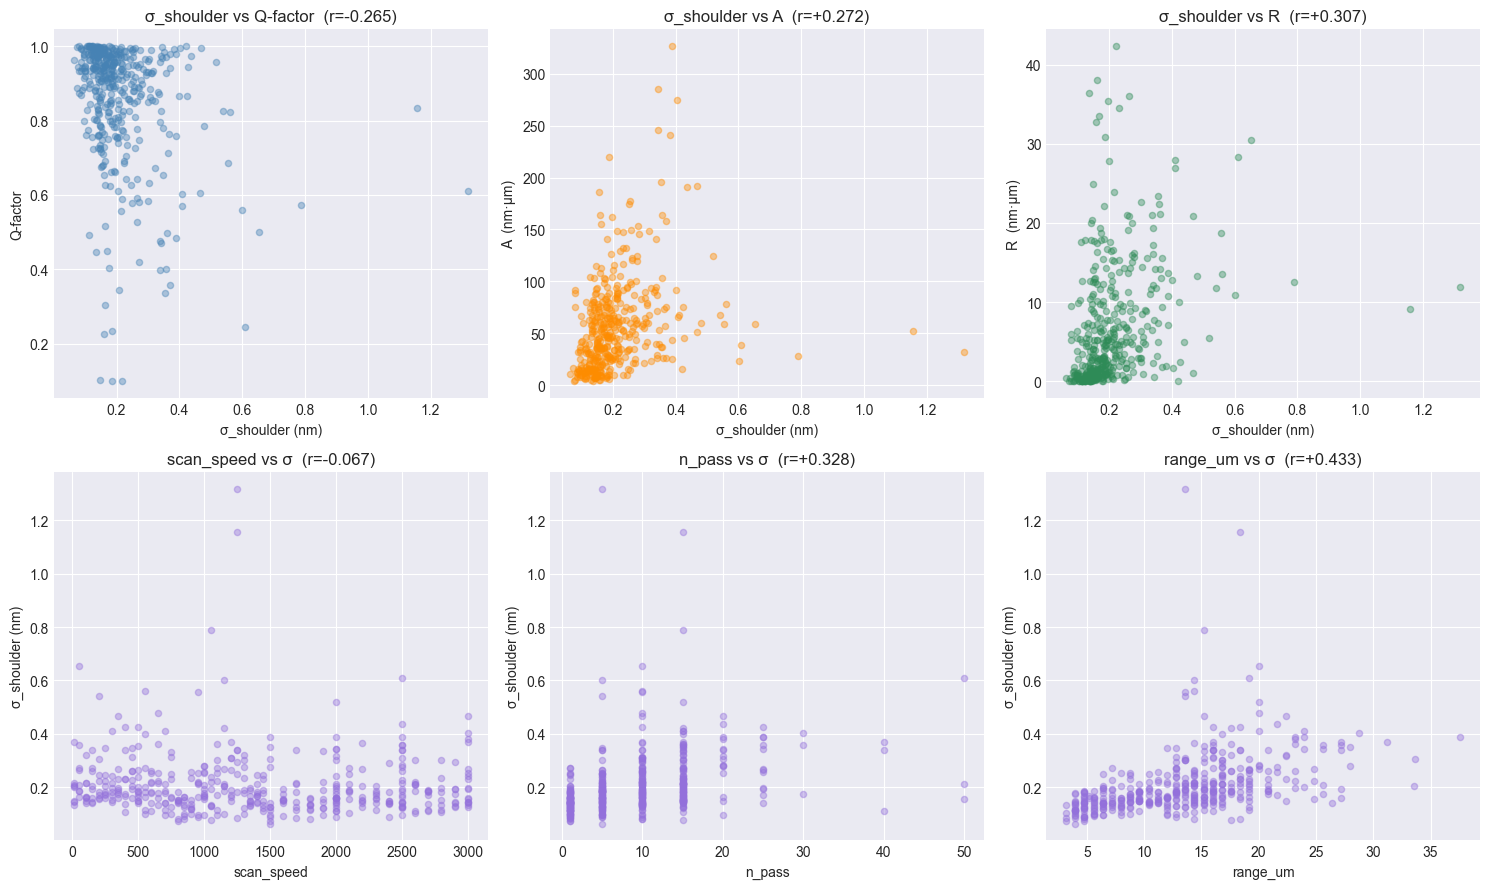

In [15]:
from scipy.stats import pearsonr

# ── Aggregate sigma_shoulder per image ───────────────────────────────────────
sig = df.groupby('filename')['sigma_shoulder'].median().reset_index()
sig.columns = ['filename', 'sigma_median']
img3 = img2.merge(sig, on='filename').dropna(subset=['sigma_median'])

print(f"Images with sigma_shoulder: {len(img3)}")
print(f"sigma_shoulder: mean={img3['sigma_median'].mean():.3f}  "
      f"std={img3['sigma_median'].std():.3f}  nm")
print()

# ── Correlations with Q, A, R ─────────────────────────────────────────────────
print("Pearson r  (\u03c3_shoulder vs Q / A / R):")
for col, label in [('q_median', 'Q'), ('A_median', 'A'), ('R_median', 'R')]:
    r, p = pearsonr(img3['sigma_median'], img3[col])
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"  {label:<6}: r={r:+.3f}  p={p:.4f} {stars}")

print()
print("Pearson r  (\u03c3_shoulder vs process params):")
for feat in FEATURES:
    r, p = pearsonr(img3['sigma_median'], img3[feat])
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"  {feat:<12}: r={r:+.3f}  p={p:.4f} {stars}")

# ── Scatter grid ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: sigma_shoulder vs Q, A, R
for ax, (col, label, color) in zip(axes[0], [
        ('q_median', 'Q-factor',       'steelblue'),
        ('A_median', 'A  (nm\u00b7\u00b5m)', 'darkorange'),
        ('R_median', 'R  (nm\u00b7\u00b5m)', 'seagreen')]):
    r, _ = pearsonr(img3['sigma_median'], img3[col])
    ax.scatter(img3['sigma_median'], img3[col], alpha=0.4, s=20, color=color)
    ax.set_xlabel('\u03c3_shoulder (nm)')
    ax.set_ylabel(label)
    ax.set_title(f'\u03c3_shoulder vs {label.split()[0]}  (r={r:+.3f})')

# Row 2: process params vs sigma_shoulder
for ax, feat in zip(axes[1], FEATURES):
    r, _ = pearsonr(img3[feat], img3['sigma_median'])
    ax.scatter(img3[feat], img3['sigma_median'], alpha=0.4, s=20, color='mediumpurple')
    ax.set_xlabel(feat)
    ax.set_ylabel('\u03c3_shoulder (nm)')
    ax.set_title(f'{feat} vs \u03c3  (r={r:+.3f})')

# Hide unused 4th subplot in row 2
axes[1][3].set_visible(False) if len(FEATURES) < 4 else None

plt.tight_layout()
plt.show()


σ_shoulder  descriptive stats:
count    423.000
mean       0.209
std        0.120
min        0.063
25%        0.143
50%        0.180
75%        0.242
max        1.319

Shapiro-Wilk: W=0.6993, p=0.0000  (not normal)


C:\Users\arayi\AppData\Local\Temp\ipykernel_32604\676013113.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax.boxplot(grp_p, labels=labels_p, patch_artist=True, notch=False)
C:\Users\arayi\AppData\Local\Temp\ipykernel_32604\676013113.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(grp_s, labels=labels_s, patch_artist=True, notch=False)


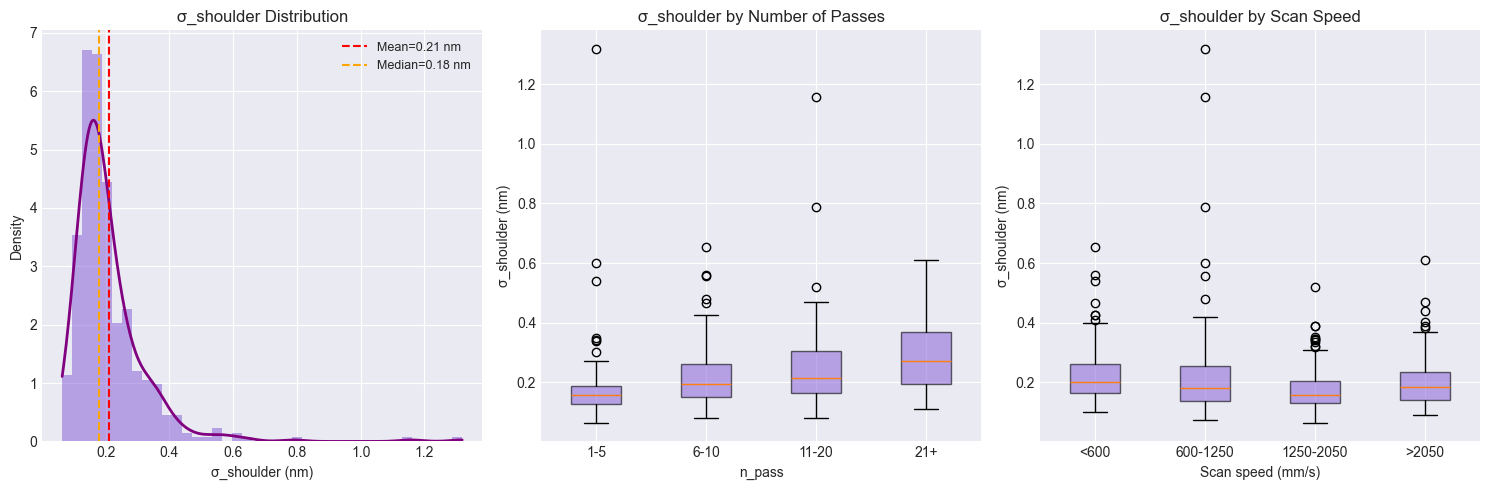

In [16]:
from scipy.stats import gaussian_kde, shapiro

vals = img3['sigma_median'].values

# ── Basic stats + normality test ─────────────────────────────────────────────
print('\u03c3_shoulder  descriptive stats:')
print(img3['sigma_median'].describe().round(3).to_string())
W, p_sw = shapiro(vals)
print(f'\nShapiro-Wilk: W={W:.4f}, p={p_sw:.4f}  '
      f'({"normal" if p_sw > 0.05 else "not normal"})')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── 1. Histogram + KDE ───────────────────────────────────────────────────────
ax = axes[0]
ax.hist(vals, bins=40, density=True, color='mediumpurple', alpha=0.6)
kde = gaussian_kde(vals, bw_method=0.3)
x_k = np.linspace(vals.min(), vals.max(), 300)
ax.plot(x_k, kde(x_k), color='purple', linewidth=2)
ax.axvline(vals.mean(),    color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean={vals.mean():.2f} nm')
ax.axvline(np.median(vals), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median={np.median(vals):.2f} nm')
ax.set_xlabel('\u03c3_shoulder (nm)')
ax.set_ylabel('Density')
ax.set_title('\u03c3_shoulder Distribution')
ax.legend(fontsize=9)

# ── 2. Box plot by n_pass bins ────────────────────────────────────────────────
ax = axes[1]
bins_p  = [0, 5, 10, 20, 50]
labels_p = ['1-5', '6-10', '11-20', '21+']
n_pass_bin = pd.cut(img3['n_pass'], bins=bins_p, labels=labels_p)
grp_p = [img3['sigma_median'][n_pass_bin == lb].dropna().values for lb in labels_p]
bp1 = ax.boxplot(grp_p, labels=labels_p, patch_artist=True, notch=False)
for patch in bp1['boxes']:
    patch.set(facecolor='mediumpurple', alpha=0.6)
ax.set_xlabel('n_pass')
ax.set_ylabel('\u03c3_shoulder (nm)')
ax.set_title('\u03c3_shoulder by Number of Passes')

# ── 3. Box plot by scan_speed bins ───────────────────────────────────────────
ax = axes[2]
bins_s  = [0, 600, 1250, 2050, 3100]
labels_s = ['<600', '600-1250', '1250-2050', '>2050']
speed_bin = pd.cut(img3['scan_speed'], bins=bins_s, labels=labels_s)
grp_s = [img3['sigma_median'][speed_bin == lb].dropna().values for lb in labels_s]
bp2 = ax.boxplot(grp_s, labels=labels_s, patch_artist=True, notch=False)
for patch in bp2['boxes']:
    patch.set(facecolor='mediumpurple', alpha=0.6)
ax.set_xlabel('Scan speed (mm/s)')
ax.set_ylabel('\u03c3_shoulder (nm)')
ax.set_title('\u03c3_shoulder by Scan Speed')

plt.tight_layout()
plt.show()


Target   Process params   + σ_shoulder        Δ
----------------------------------------------
Q                 0.128          0.089   -0.039
A                 0.491          0.444   -0.046
R                 0.431         -0.255   -0.686


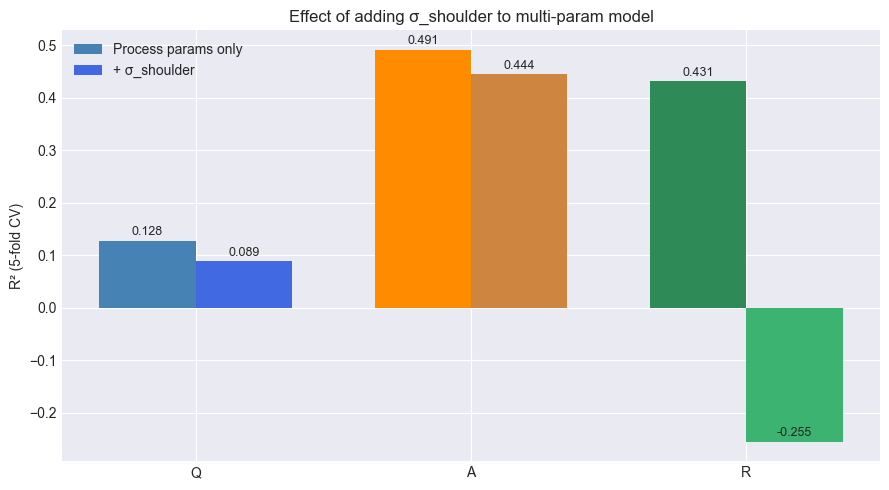

In [17]:
# ── Multi-param Poly-2+Ridge  with and without sigma_shoulder ─────────────────
FEATURES_EXT = FEATURES + ['sigma_median']
X3   = img3[FEATURES_EXT].values
y_Q3 = img3['q_median'].values
y_A3 = img3['A_median'].values
y_R3 = img3['R_median'].values

def poly_ridge_cv(X, y):
    pipe = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        Ridge(alpha=1.0),
    )
    return cross_val_score(pipe, X, y, cv=5, scoring='r2').mean()

# Use img3 subset for a fair comparison (same rows both ways)
X3_base = img3[FEATURES].values
cv_Q_base = poly_ridge_cv(X3_base, y_Q3)
cv_A_base = poly_ridge_cv(X3_base, y_A3)
cv_R_base = poly_ridge_cv(X3_base, y_R3)

cv_Q_ext  = poly_ridge_cv(X3, y_Q3)
cv_A_ext  = poly_ridge_cv(X3, y_A3)
cv_R_ext  = poly_ridge_cv(X3, y_R3)

print(f"{'Target':<6} {'Process params':>16} {'+ \u03c3_shoulder':>14} {'\u0394':>8}")
print('-' * 46)
for label, base, ext in [('Q', cv_Q_base, cv_Q_ext),
                          ('A', cv_A_base, cv_A_ext),
                          ('R', cv_R_base, cv_R_ext)]:
    print(f"{label:<6} {base:>16.3f} {ext:>14.3f} {ext-base:>+8.3f}")

# ── Comparison bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
w = 0.35
b1 = ax.bar(x - w/2, [cv_Q_base, cv_A_base, cv_R_base], w,
            label='Process params only', color=['steelblue', 'darkorange', 'seagreen'])
b2 = ax.bar(x + w/2, [cv_Q_ext, cv_A_ext, cv_R_ext], w,
            label='+ \u03c3_shoulder',
            color=['royalblue', 'peru', 'mediumseagreen'])
ax.set_xticks(x)
ax.set_xticklabels(['Q', 'A', 'R'])
ax.set_ylabel('R\u00b2 (5-fold CV)')
ax.set_title('Effect of adding \u03c3_shoulder to multi-param model')
ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


Filter: [0.029, 0.390] nm  (mean ± 1.5·std)
Removed 21/423 images (5.0%)
Remaining: 402

                 r(Q)     r(A)     r(R)
----------------------------------------
All           -0.265*  +0.272*  +0.307*
Filtered      -0.234*  +0.435*  +0.314*

Target     Unfiltered     Filtered        Δ
------------------------------------------
Q               0.089        0.046   -0.043
A               0.444        0.488   +0.044
R              -0.255        0.330   +0.584


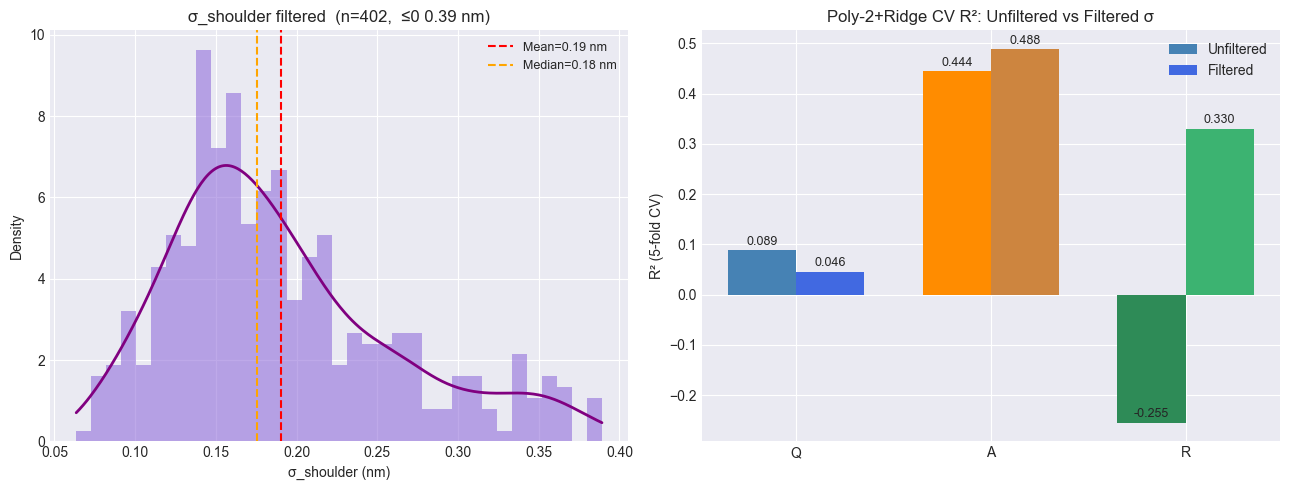

In [18]:
# ── Filter sigma outliers ────────────────────────────────────────────────────
# Distribution is right-skewed; clip the long tail at mean + N_SIGMA·std.
N_SIGMA = 1.5   # adjust here if needed

s_mean = img3['sigma_median'].mean()
s_std  = img3['sigma_median'].std()
lo     = max(0.0, s_mean - N_SIGMA * s_std)
hi     =          s_mean + N_SIGMA * s_std

img3_filt = img3[(img3['sigma_median'] >= lo) & (img3['sigma_median'] <= hi)].copy()

n_removed = len(img3) - len(img3_filt)
print(f'Filter: [{lo:.3f}, {hi:.3f}] nm  (mean ± {N_SIGMA}·std)')
print(f'Removed {n_removed}/{len(img3)} images ({n_removed/len(img3)*100:.1f}%)')
print(f'Remaining: {len(img3_filt)}')
print()

# ── Correlations: all vs filtered ────────────────────────────────────────────
print(f"{'':12} {'r(Q)':>8} {'r(A)':>8} {'r(R)':>8}")
print('-' * 40)
for label, dset in [('All', img3), ('Filtered', img3_filt)]:
    row = []
    for col in ['q_median', 'A_median', 'R_median']:
        r, p = pearsonr(dset['sigma_median'], dset[col])
        row.append(f'{r:+.3f}{"*" if p < 0.05 else " "}')
    print(f'{label:<12} {row[0]:>8} {row[1]:>8} {row[2]:>8}')

# ── Multi-param CV R² on filtered data ───────────────────────────────────────
X3f = img3_filt[FEATURES_EXT].values
cv_Qf = poly_ridge_cv(X3f, img3_filt['q_median'].values)
cv_Af = poly_ridge_cv(X3f, img3_filt['A_median'].values)
cv_Rf = poly_ridge_cv(X3f, img3_filt['R_median'].values)

print()
print(f"{'Target':<8} {'Unfiltered':>12} {'Filtered':>12} {'Δ':>8}")
print('-' * 42)
for lbl, base, filt in [('Q', cv_Q_ext, cv_Qf),
                          ('A', cv_A_ext, cv_Af),
                          ('R', cv_R_ext, cv_Rf)]:
    print(f'{lbl:<8} {base:>12.3f} {filt:>12.3f} {filt - base:>+8.3f}')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: filtered distribution
ax = axes[0]
vals_f = img3_filt['sigma_median'].values
ax.hist(vals_f, bins=35, density=True, color='mediumpurple', alpha=0.6)
kde_f = gaussian_kde(vals_f, bw_method=0.3)
x_kf  = np.linspace(vals_f.min(), vals_f.max(), 300)
ax.plot(x_kf, kde_f(x_kf), color='purple', linewidth=2)
ax.axvline(vals_f.mean(),     color='red',    linestyle='--',
           linewidth=1.5, label=f'Mean={vals_f.mean():.2f} nm')
ax.axvline(np.median(vals_f), color='orange', linestyle='--',
           linewidth=1.5, label=f'Median={np.median(vals_f):.2f} nm')
ax.set_xlabel('σ_shoulder (nm)')
ax.set_ylabel('Density')
ax.set_title(f'σ_shoulder filtered  (n={len(img3_filt)},  ≤0 {hi:.2f} nm)')
ax.legend(fontsize=9)

# Right: CV R² unfiltered vs filtered
ax = axes[1]
x2 = np.arange(3)
w  = 0.35
b1 = ax.bar(x2 - w/2, [cv_Q_ext, cv_A_ext, cv_R_ext], w,
            label='Unfiltered', color=['steelblue', 'darkorange', 'seagreen'])
b2 = ax.bar(x2 + w/2, [cv_Qf, cv_Af, cv_Rf], w,
            label='Filtered',   color=['royalblue', 'peru', 'mediumseagreen'])
ax.set_xticks(x2)
ax.set_xticklabels(['Q', 'A', 'R'])
ax.set_ylabel('R² (5-fold CV)')
ax.set_title('Poly-2+Ridge CV R²: Unfiltered vs Filtered σ')
ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [19]:
# ── Output folder ────────────────────────────────────────────────────────────
OUT = Path('results')
OUT.mkdir(exist_ok=True)

# ── Helper ───────────────────────────────────────────────────────────────────
def save_fit_plot(x, y, results, xlabel, title, filename, top_n=3):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(x, y, alpha=0.5, s=25, color='steelblue', label='Data', zorder=3)
    x_line = np.linspace(x.min(), x.max(), 300)
    colors = ['red', 'orange', 'green', 'purple']
    for i, (name, res) in enumerate(list(results.items())[:top_n]):
        if res['params'] is not None:
            y_line = res['fn'](x_line, *res['params'])
            ax.plot(x_line, y_line, color=colors[i], linewidth=2,
                    label=f"{name}  R²={res['r2']:.3f}  RMSE={res['rmse']:.3f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Median Q-Factor')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT / filename, dpi=150)
    plt.close()
    print(f'  Saved: {OUT / filename}')

# ── 1. Single-parameter fit plots ─────────────────────────────────────────────
print('Single-parameter fit plots...')
save_fit_plot(img['scan_speed'], img['q_median'], results_speed,
              'Scan Speed (mm/s)', 'Q vs Scan Speed',       'fit_scan_speed.png')
save_fit_plot(img['n_pass'],     img['q_median'], results_pass,
              'Number of Passes',  'Q vs Number of Passes', 'fit_n_pass.png')
save_fit_plot(img['range_um'],   img['q_median'], results_range,
              'Range (µm)',        'Q vs Range',             'fit_range_um.png')
save_fit_plot(img['power'],      img['q_median'], results_power,
              'Power (W)',          'Q vs Power',             'fit_power.png')

# ── 2. Multi-parameter comparison (Q only) ───────────────────────────────────
print('Multi-parameter comparison plot...')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bar_colors = ['steelblue' if c > 0 else 'salmon' for c in lr_std.coef_]
axes[0].barh(FEATURES, lr_std.coef_, color=bar_colors)
axes[0].axvline(0, color='k', linewidth=0.8)
axes[0].set_title('Multi-linear — Standardized Coefficients')
axes[0].set_xlabel('Coefficient (std units)')
labels = ['Best single-param\n(scan_speed, Poly-3)', 'Multi-linear', 'Poly-2 + Ridge']
cv_r2s = [cv_r2_speed, cv_r2_lr, cv_r2_poly]
clrs   = ['gray', 'steelblue', 'darkorange']
bars   = axes[1].bar(labels, cv_r2s, color=clrs, width=0.5)
axes[1].set_ylabel('R² (5-fold CV)')
axes[1].set_title('Q Model Comparison — CV R²')
axes[1].set_ylim(0, max(max(cv_r2s) * 1.4, 0.1))
for bar, val in zip(bars, cv_r2s):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.003, f'{val:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(OUT / 'multiparam_comparison.png', dpi=150)
plt.close()
print(f'  Saved: {OUT}/multiparam_comparison.png')

# ── 3. A and R component analysis plot ───────────────────────────────────────
print('A and R component analysis plot...')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos  = np.arange(len(FEATURES))
width  = 0.25
q_r2s  = [list(all_results[f].values())[0]['r2'] for f in FEATURES]
a_r2s  = [list(results_A[f].values())[0]['r2']   for f in FEATURES]
r_r2s  = [list(results_R[f].values())[0]['r2']   for f in FEATURES]
axes[0].bar(x_pos - width, q_r2s, width, label='Q', color='steelblue')
axes[0].bar(x_pos,         a_r2s, width, label='A', color='darkorange')
axes[0].bar(x_pos + width, r_r2s, width, label='R', color='seagreen')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(FEATURES)
axes[0].set_ylabel('Best R² (train)')
axes[0].set_title('Single-param: Q vs A vs R')
axes[0].legend()
labels2 = ['Q', 'A', 'R']
cv_vals = [cv_r2_poly, cv_A, cv_R]
clrs2   = ['steelblue', 'darkorange', 'seagreen']
bars2   = axes[1].bar(labels2, cv_vals, color=clrs2, width=0.4)
axes[1].set_ylabel('R² (5-fold CV)')
axes[1].set_title('Multi-param Poly-2+Ridge  CV R²')
axes[1].set_ylim(0, max(max(cv_vals) * 1.4, 0.1))
for bar, val in zip(bars2, cv_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005, f'{val:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(OUT / 'ar_component_analysis.png', dpi=150)
plt.close()
print(f'  Saved: {OUT}/ar_component_analysis.png')

# ── 4. Sigma shoulder: filtered distribution + CV comparison ─────────────────
print('Sigma shoulder analysis plot...')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vals_f = img3_filt['sigma_median'].values
axes[0].hist(vals_f, bins=35, density=True, color='mediumpurple', alpha=0.6)
kde_f = gaussian_kde(vals_f, bw_method=0.3)
x_kf  = np.linspace(vals_f.min(), vals_f.max(), 300)
axes[0].plot(x_kf, kde_f(x_kf), color='purple', linewidth=2)
axes[0].axvline(vals_f.mean(),     color='red',    linestyle='--', linewidth=1.5,
                label=f'Mean={vals_f.mean():.2f} nm')
axes[0].axvline(np.median(vals_f), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median={np.median(vals_f):.2f} nm')
axes[0].set_xlabel('σ_shoulder (nm)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'σ_shoulder filtered  (n={len(img3_filt)}, ≤{hi:.2f} nm)')
axes[0].legend(fontsize=9)
x2 = np.arange(3)
w  = 0.35
b1 = axes[1].bar(x2 - w/2, [cv_Q_ext, cv_A_ext, cv_R_ext], w,
                 label='+ σ unfiltered', color=['steelblue', 'darkorange', 'seagreen'])
b2 = axes[1].bar(x2 + w/2, [cv_Qf, cv_Af, cv_Rf], w,
                 label=f'+ σ filtered ({N_SIGMA}σ)', color=['royalblue', 'peru', 'mediumseagreen'])
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Q', 'A', 'R'])
axes[1].set_ylabel('R² (5-fold CV)')
axes[1].set_title('Effect of σ_shoulder  —  Unfiltered vs Filtered')
axes[1].legend()
axes[1].axhline(0, color='k', linewidth=0.6, linestyle=':')
for bars in [b1, b2]:
    for bar in bars:
        ypos = bar.get_height() + 0.005 if bar.get_height() >= 0 else bar.get_height() - 0.02
        axes[1].text(bar.get_x() + bar.get_width() / 2, ypos,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'sigma_shoulder_analysis.png', dpi=150)
plt.close()
print(f'  Saved: {OUT}/sigma_shoulder_analysis.png')

# ── 5. Summary CSV ────────────────────────────────────────────────────────────
print('Summary CSV...')
rows = []
# Single-param Q
for param, res in all_results.items():
    best = res[list(res.keys())[0]]
    rows.append({'scope': 'single-param', 'target': 'Q', 'parameter': param,
                 'model': list(res.keys())[0],
                 'train_R2': round(best['r2'], 4), 'RMSE': round(best['rmse'], 4), 'CV_R2': None})
# Single-param A and R
for target, res_dict in [('A', results_A), ('R', results_R)]:
    for param, res in res_dict.items():
        best = res[list(res.keys())[0]]
        rows.append({'scope': 'single-param', 'target': target, 'parameter': param,
                     'model': list(res.keys())[0],
                     'train_R2': round(best['r2'], 4), 'RMSE': round(best['rmse'], 4), 'CV_R2': None})
# Multi-param (process params only)
rows.append({'scope': 'multi-param', 'target': 'Q', 'parameter': 'all', 'model': 'Multi-linear',
             'train_R2': round(r2_lr,   4), 'RMSE': round(rmse_lr,   4), 'CV_R2': round(cv_r2_lr,   4)})
rows.append({'scope': 'multi-param', 'target': 'Q', 'parameter': 'all', 'model': 'Poly-2+Ridge',
             'train_R2': round(r2_poly, 4), 'RMSE': round(rmse_poly, 4), 'CV_R2': round(cv_r2_poly, 4)})
rows.append({'scope': 'multi-param', 'target': 'A', 'parameter': 'all', 'model': 'Poly-2+Ridge',
             'train_R2': None, 'RMSE': None, 'CV_R2': round(cv_A, 4)})
rows.append({'scope': 'multi-param', 'target': 'R', 'parameter': 'all', 'model': 'Poly-2+Ridge',
             'train_R2': None, 'RMSE': None, 'CV_R2': round(cv_R, 4)})
# Multi-param + sigma filtered
rows.append({'scope': 'multi-param+sigma', 'target': 'Q', 'parameter': 'all', 'model': f'Poly-2+Ridge+sigma({N_SIGMA}s)',
             'train_R2': None, 'RMSE': None, 'CV_R2': round(cv_Qf, 4)})
rows.append({'scope': 'multi-param+sigma', 'target': 'A', 'parameter': 'all', 'model': f'Poly-2+Ridge+sigma({N_SIGMA}s)',
             'train_R2': None, 'RMSE': None, 'CV_R2': round(cv_Af, 4)})
rows.append({'scope': 'multi-param+sigma', 'target': 'R', 'parameter': 'all', 'model': f'Poly-2+Ridge+sigma({N_SIGMA}s)',
             'train_R2': None, 'RMSE': None, 'CV_R2': round(cv_Rf, 4)})
pd.DataFrame(rows).to_csv(OUT / 'regression_summary.csv', index=False)
print(f'  Saved: {OUT}/regression_summary.csv')

# ── 6. Text summary ───────────────────────────────────────────────────────────
SEP = '=' * 64
print()
print(SEP)
print('REGRESSION ANALYSIS SUMMARY')
print(SEP)
print(f'Dataset : {len(img)} images, 1 material (Silicon Wafer)')
print(f'Q-factor: mean={img["q_median"].mean():.3f}, std={img["q_median"].std():.3f}')
print(f'          (skewed high — most samples near Q=1)')
print()
print('--- Single-parameter Q fits (train R²) ---')
for param, res in all_results.items():
    best = res[list(res.keys())[0]]
    print(f'  {param:<12}: {list(res.keys())[0]:<12}  R²={best["r2"]:.3f}')
print(f'  scan_speed CV R²={cv_r2_speed:.3f}  (vs train {list(all_results["scan_speed"].values())[0]["r2"]:.3f} — overfitting)')
print()
print('--- Multi-parameter Q fits (5-fold CV R²) ---')
print(f'  Multi-linear       : {cv_r2_lr:.3f}  — linear combination adds nothing')
print(f'  Poly-2 + Ridge     : {cv_r2_poly:.3f}  — 3x better, interactions capture fluence effect')
print()
print('--- A and R component analysis (Poly-2+Ridge, CV R²) ---')
print(f'  A (ablated area)   : {cv_A:.3f}  — strongly driven by n_pass and range_um')
print(f'  R (redeposited)    : {cv_R:.3f}  — also predictable, driven by scan_speed')
print(f'  Q                  : {cv_r2_poly:.3f}  — hard to predict: A and R co-vary, ratio cancels signal')
print(f'  Key insight: model A and R separately, not Q directly')
print()
print('--- Shoulder roughness (σ_shoulder) ---')
print(f'  Distribution: mean={img3["sigma_median"].mean():.3f} nm, std={img3["sigma_median"].std():.3f} nm')
print(f'  Heavily right-skewed (max={img3["sigma_median"].max():.3f} nm), not normal')
print(f'  Outlier filter: mean + {N_SIGMA}σ ≤ {hi:.3f} nm  ({len(img3)-len(img3_filt)} images removed, {(len(img3)-len(img3_filt))/len(img3)*100:.1f}%)')
print(f'  CV R² with σ filtered ({N_SIGMA}σ):')
print(f'    Q: {cv_Qf:.3f}  A: {cv_Af:.3f}  R: {cv_Rf:.3f}')
print(f'  σ outliers catastrophically broke R model (CV R²={cv_R_ext:.3f} unfiltered)')
print(f'  After filtering: R improves to {cv_Rf:.3f}, A stable at {cv_Af:.3f}')
print()
print('--- Honest assessment ---')
print('  Q prediction (CV R²=0.13) is not usable for process optimization.')
print('  A and R are genuinely predictable (CV R²~0.49/0.43 from process params).')
print('  Sigma shoulder is useful but requires outlier filtering.')
print('  Root cause of weak Q prediction: A and R co-vary — more exposure increases')
print('  both ablation and redeposition in similar proportion.')
print('  scan_speed is the key lever: faster = less redeposition without reducing ablation.')
print()
print('--- What would improve results ---')
print('  - New materials (new dimension in parameter space)')
print('  - Wider power sweep (only 1.65W vs 1.85W currently)')
print('  - Designed grid experiments')
print(SEP)


NameError: name 'Path' is not defined